In [74]:
#Import libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt  

#Load CSV file
df = pd.read_csv(r"C:\Users\erick\Desktop\Hello World\Sample-Superstore.csv", encoding="latin1")

#Display the first 5 rows
print(df.head())
#Information about thr data frame
print(df.info())
#Statistics for numeric columns
print(df.describe())   


   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0       42420   Sout

In [75]:
#Find duplicated rows
duplicates = df[df.duplicated()]
print(duplicates)


Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit]
Index: []

[0 rows x 21 columns]


In [76]:
#Convert 'Order Date' and 'Ship Date' columns to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=False)

print(df.dtypes[['Order Date',]])


Order Date    datetime64[ns]
dtype: object


In [77]:
print(df[['Sales','Quantity','Discount','Profit']].describe())


              Sales     Quantity     Discount       Profit
count   9994.000000  9994.000000  9994.000000  9994.000000
mean     229.858001     3.789574     0.156203    28.656896
std      623.245101     2.225110     0.206452   234.260108
min        0.444000     1.000000     0.000000 -6599.978000
25%       17.280000     2.000000     0.000000     1.728750
50%       54.490000     3.000000     0.200000     8.666500
75%      209.940000     5.000000     0.200000    29.364000
max    22638.480000    14.000000     0.800000  8399.976000


In [78]:
# Convert 'Order Date' to datetime format
# Errors that cannot be converted are replaced with NaT
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce', dayfirst=False)
print(df[df['Order Date'].isnull()])

Empty DataFrame
Columns: [Row ID, Order ID, Order Date, Ship Date, Ship Mode, Customer ID, Customer Name, Segment, Country, City, State, Postal Code, Region, Product ID, Category, Sub-Category, Product Name, Sales, Quantity, Discount, Profit]
Index: []

[0 rows x 21 columns]


In [79]:
df['Order_Year'] = df['Order Date'].dt.year


In [80]:
## Check the data type to confirm it was successfully converted to datetime
print(df.dtypes[['Order Date',]])


Order Date    datetime64[ns]
dtype: object


In [81]:
## Create a new column 'Order_Year' by extracting the year from 'Order Date'
sales_by_year = df.groupby('Order_Year')['Sales'].sum()
print(sales_by_year)


Order_Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


In [82]:
#Profit by category
profit_by_category = df.groupby('Category')['Profit'].sum()
print(profit_by_category)


Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64


In [83]:
#Sales by segment
sales_by_segment = df.groupby('Segment')['Sales'].sum()
print(sales_by_segment)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


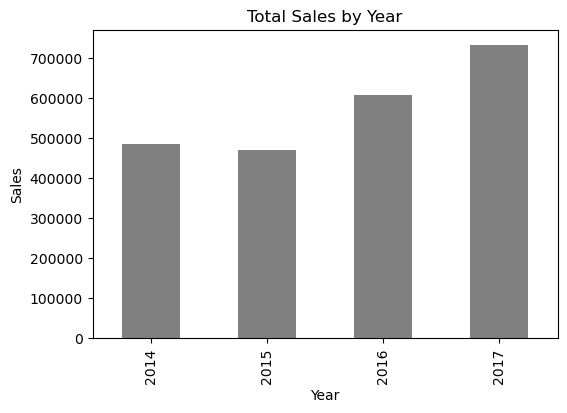

In [84]:
#Sales by year
sales_by_year.plot(kind='bar', color='Grey', figsize=(6,4))
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()
# Insight: 2017 had the highest total sales

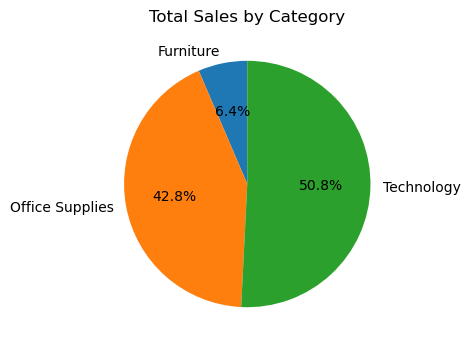

In [85]:
#Profit by Category
profit_by_category.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(4,4))
plt.title('Total Sales by Category')
plt.ylabel('')  
plt.show()
## Insight: The Technology category generated the highest total sales
# This shows that Technology products contributed the most to overall revenue in the dataset

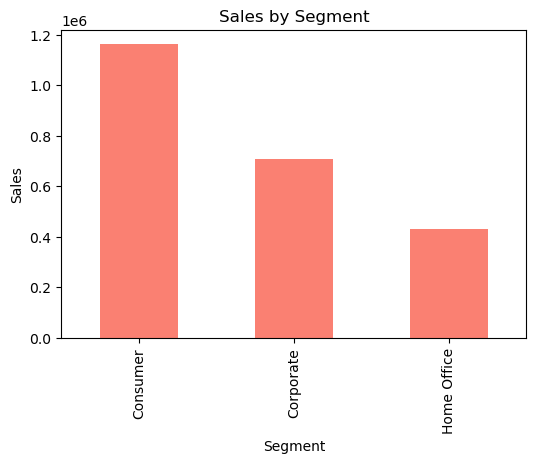

In [86]:
#Sales by Segment
sales_by_segment.plot(kind='bar', color='Salmon', figsize=(6,4))
plt.title('Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Sales')
plt.show()
## Insight: The Consumer segment has the highest total sales
# This indicates that most of the revenue comes from consumer customers compared to Corporate or Home Office segments